## COMPARACIÓN FINAL DE ESTRATEGIAS

Fase 8 — Consolidación de las cinco estrategias evaluadas: Markowitz clásico, Equal Weight, Markowitz + SVR, Markowitz + LSTM y S&P 500. Este notebook reutiliza los resultados ya guardados en las fases anteriores (no vuelve a entrenar ni optimizar nada), y arma la tabla y gráfica finales para el informe.

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results" / "comparacion_final"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MARKOWITZ_BACKTEST = PROJECT_ROOT / "results" / "markowitz" / "backtest_comparison.csv"
SVR_BACKTEST = PROJECT_ROOT / "results" / "svr" / "backtest_markowitz_svr.csv"
LSTM_BACKTEST = PROJECT_ROOT / "results" / "lstm" / "backtest_markowitz_lstm.csv"

print("Directorio de resultados:", RESULTS_DIR)


Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\comparacion_final


## Carga y consolidación de los backtests guardados

Cada notebook anterior (04, 05, 06) guardó su propio backtest con columnas distintas. Aquí se combinan en un solo DataFrame, alineado por fecha, quedándonos con una sola columna de cada estrategia (Equal Weight y S&P 500 se repiten en los tres archivos, así que se toman de uno solo).

In [3]:
markowitz_bt = pd.read_csv(MARKOWITZ_BACKTEST, index_col=0, parse_dates=True)
svr_bt = pd.read_csv(SVR_BACKTEST, index_col=0, parse_dates=True)
lstm_bt = pd.read_csv(LSTM_BACKTEST, index_col=0, parse_dates=True)

comparacion_final = pd.DataFrame({
    "Markowitz Clásico": markowitz_bt["Max Sharpe"],
    "Equal Weight": markowitz_bt["Equal Weight"],
    "Markowitz + SVR": svr_bt["Markowitz + SVR"],
    "Markowitz + LSTM": lstm_bt["Markowitz + LSTM"],
    "S&P 500": markowitz_bt["S&P 500"]
}).dropna()

comparacion_final.head()


,Markowitz Clásico,Equal Weight,Markowitz + SVR,Markowitz + LSTM,S&P 500
Date,,,,,
2018-01-03,1.013478,1.010428,1.016804,1.017998,1.006399
2018-01-04,1.019282,1.016125,1.026183,1.023636,1.010453
2018-01-05,1.027817,1.026061,1.037841,1.031149,1.017561
2018-01-08,1.040826,1.034999,1.048597,1.036743,1.019252
2018-01-09,1.041581,1.034932,1.050789,1.039932,1.020580


## Gráfica consolidada: crecimiento de $1 invertido, las 5 estrategias juntas

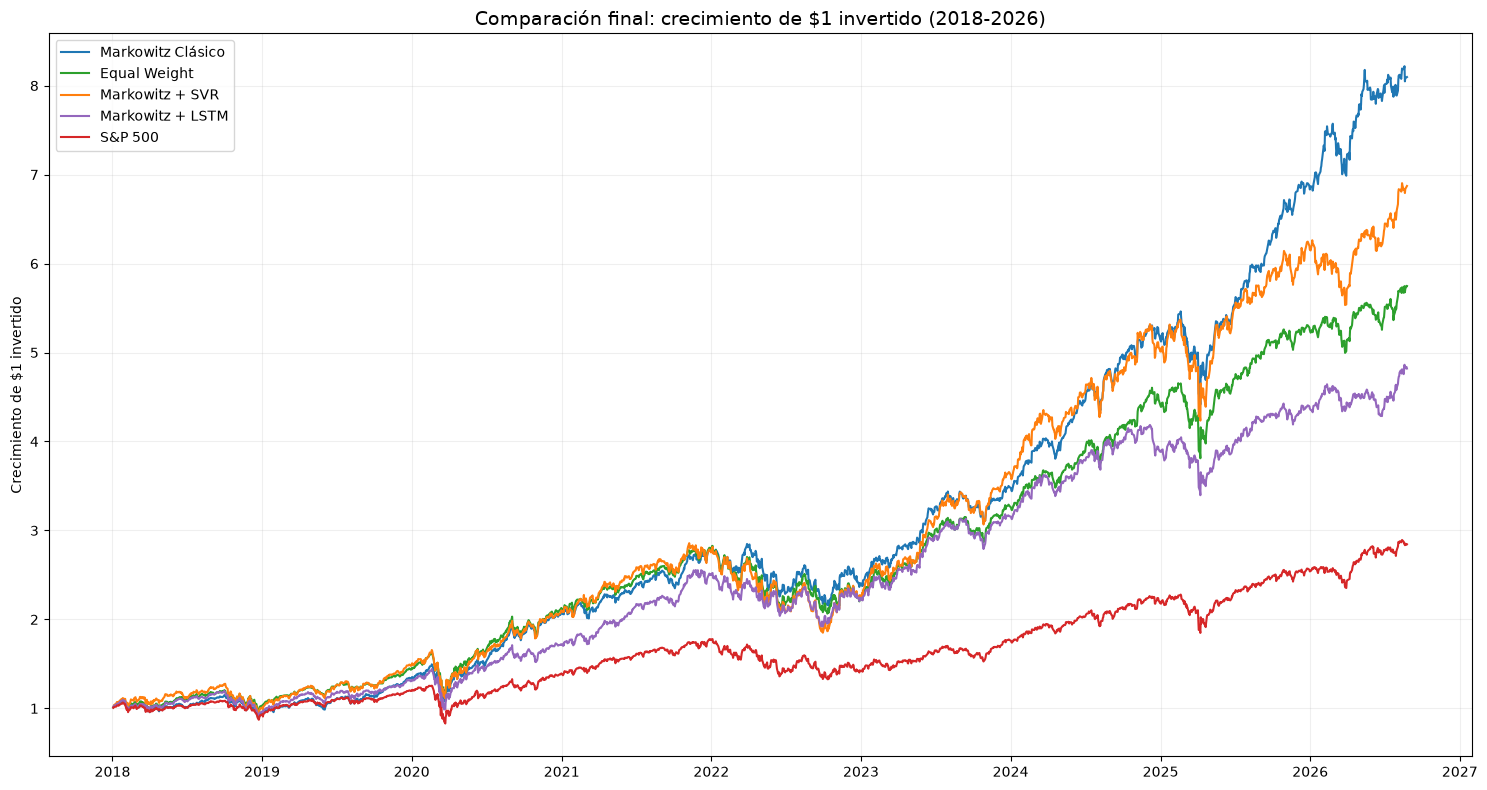

In [4]:
fig, ax = plt.subplots(figsize=(15, 8))

colors = {
    "Markowitz Clásico": "#1f77b4",
    "Equal Weight": "#2ca02c",
    "Markowitz + SVR": "#ff7f0e",
    "Markowitz + LSTM": "#9467bd",
    "S&P 500": "#d62728"
}

for col in comparacion_final.columns:
    ax.plot(comparacion_final.index, comparacion_final[col], label=col, color=colors.get(col), linewidth=1.5)

ax.set_title("Comparación final: crecimiento de $1 invertido (2018-2026)", fontsize=14)
ax.set_ylabel("Crecimiento de $1 invertido")
ax.legend(loc="upper left")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_comparacion_final_backtest.png", dpi=300, bbox_inches="tight")
plt.show()


## Tabla resumen final de métricas

In [5]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = 0.02) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    calmar = ann_return / abs(max_drawdown)
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown,
        "Calmar Ratio": calmar
    }

summary_final = pd.DataFrame({
    col: annualized_metrics(comparacion_final[col]) for col in comparacion_final.columns
}).T

summary_final = summary_final.sort_values("Sharpe Ratio", ascending=False)

summary_final.round(4)


,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown,Calmar Ratio
Markowitz Clásico,0.2612,0.1991,1.2113,-0.2816,0.9273
Equal Weight,0.2224,0.2025,0.9997,-0.2998,0.7419
Markowitz + SVR,0.2509,0.2407,0.9592,-0.3524,0.7121
Markowitz + LSTM,0.2018,0.2058,0.8835,-0.3144,0.6419
S&P 500,0.1392,0.1922,0.6201,-0.3392,0.4102


### Nota sobre el Calmar Ratio

Se agregó una métrica adicional no calculada antes: el **Calmar Ratio** (retorno anualizado entre el máximo drawdown en valor absoluto). Mide el retorno obtenido por unidad de la peor caída sufrida — es un complemento útil al Sharpe porque el Sharpe penaliza toda la volatilidad por igual (subidas y bajadas), mientras que Calmar se enfoca solo en el peor escenario de pérdida, que es lo que más le importa a un inversionista en la práctica.

## Ranking final y conclusión cuantitativa

In [6]:
print("RANKING POR SHARPE RATIO:")
print(summary_final["Sharpe Ratio"].round(4).to_string())
print()
print("RANKING POR RETORNO ANUALIZADO:")
print(summary_final["Retorno anualizado"].sort_values(ascending=False).round(4).to_string())
print()
print("RANKING POR MENOR DRAWDOWN (mejor a peor):")
print(summary_final["Máximo Drawdown"].sort_values(ascending=False).round(4).to_string())


RANKING POR SHARPE RATIO:
Markowitz Clásico    1.2113
Equal Weight         0.9997
Markowitz + SVR      0.9592
Markowitz + LSTM     0.8835
S&P 500              0.6201

RANKING POR RETORNO ANUALIZADO:
Markowitz Clásico    0.2612
Markowitz + SVR      0.2509
Equal Weight         0.2224
Markowitz + LSTM     0.2018
S&P 500              0.1392

RANKING POR MENOR DRAWDOWN (mejor a peor):
Markowitz Clásico   -0.2816
Equal Weight        -0.2998
Markowitz + LSTM    -0.3144
S&P 500             -0.3392
Markowitz + SVR     -0.3524


## Conclusión de la Fase 8 (para el informe)

Con las cinco estrategias evaluadas bajo las mismas condiciones (mismo periodo 2018-2026, mismo universo de 20 activos, backtest de pesos fijos sin rebalanceo), el ranking por Sharpe Ratio es:

1. **Markowitz Clásico** — el `mu` histórico simple superó a todas las alternativas.
2. **Equal Weight** — el portafolio ingenuo (1/N) fue sorprendentemente competitivo, consistente con la literatura de DeMiguel, Garlappi & Uppal (2009).
3. **Markowitz + SVR** — mejor retorno absoluto que LSTM, pero con más riesgo (mayor volatilidad y drawdown).
4. **Markowitz + LSTM** — más conservador que SVR (menor volatilidad y drawdown), pero también menor retorno.
5. **S&P 500** — el benchmark de mercado, superado por las cuatro estrategias construidas.

**Hallazgo central del proyecto**: sustituir el retorno esperado histórico por estimaciones de machine learning (SVR o LSTM) **no mejoró el desempeño del portafolio** en este universo de datos, horizonte de predicción y set de features. Esto es consistente con:
- El R² negativo observado en ambos modelos durante la fase de entrenamiento (evidencia predictiva directa).
- La Hipótesis de Mercados Eficientes en su forma débil.
- Los hallazgos de la literatura revisada (el estudio de SVR vs. LSTM que se encontró documenta un patrón similar: competencia en tendencia visual, pero divergencia real al aplicarse a construcción de portafolios).

Esto no invalida el proyecto — es un **resultado de investigación válido y bien evidenciado**: la sofisticación de un modelo no garantiza mejor desempeño si la señal subyacente que intenta capturar (retornos futuros de corto plazo) es genuinamente difícil de predecir con los datos y features disponibles.

## Guardar resultados finales

In [7]:
comparacion_final.to_csv(RESULTS_DIR / "backtest_comparacion_final.csv")
summary_final.to_csv(RESULTS_DIR / "summary_comparacion_final.csv")

print("Resultados finales guardados en:", RESULTS_DIR)


Resultados finales guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\comparacion_final
